#HW 5 - CNN Sketch Classification (10 pts)

For homework assignment HW 5, you will implement a sketch classifier using the Google QuickDraw dataset:
1. Select at least 5 classes for training and testing.

2. Baseline Implementation: implement the classifier using Lab 2 architecture to establish a performance baseline. (1/10 pts)

3. Re-implement the classifier using CNN and conduct experiments to compare the performance of the classic NN against the CNN. (5/10 pts)

4. Experiment Report (max 6 pages): You are required to conduct a comparative performance analysis of your models with at least 100 test sketches (from the dataset) for each class. You **MUST** experiment with different model configurations for your CNN (e.g. different hidden layer size, more or less convolution layers, batch norm, dropout, etc.) to make it better. Document your findings with comparative screenshots of classification outputs and specify the configuration that gives you the best results. Report the accuracy rate for different model configurations. (4/10 pts)


Note:
1. You can use smaller training data size (so faster training) as long as you get reasonable classification results.
2. You can split the dataset, use a subset as training set and use another 100 or more sketches as the test set.

In [1]:
import os
import urllib.request

# Define categories to download
# See all the categories at:
# https://github.com/googlecreativelab/quickdraw-dataset/blob/master/categories.txt
categories = ['apple', 'basketball', 'camera', 'cloud', 'donut',
              'eye', 'flower', 'mug', 'rainbow', 'tent']
base_url = "https://storage.googleapis.com/quickdraw_dataset/full/numpy_bitmap/"

if not os.path.exists('data'):
    os.mkdir('data')

for cat in categories:
    url = f"{base_url}{cat}.npy"
    path = f"data/{cat}.npy"
    if not os.path.exists(path):
        print(f"Downloading {cat}...")
        urllib.request.urlretrieve(url, path)

Training on cuda...
Epoch [1/10] - Train Acc: 79.60%, Test Acc: 84.89%
Epoch [2/10] - Train Acc: 85.62%, Test Acc: 86.98%
Epoch [3/10] - Train Acc: 87.42%, Test Acc: 88.02%
Epoch [4/10] - Train Acc: 88.42%, Test Acc: 88.53%
Epoch [5/10] - Train Acc: 89.33%, Test Acc: 88.95%
Epoch [6/10] - Train Acc: 89.90%, Test Acc: 89.47%
Epoch [7/10] - Train Acc: 90.32%, Test Acc: 89.77%
Epoch [8/10] - Train Acc: 90.64%, Test Acc: 89.97%
Epoch [9/10] - Train Acc: 91.15%, Test Acc: 89.92%
Epoch [10/10] - Train Acc: 91.40%, Test Acc: 90.08%


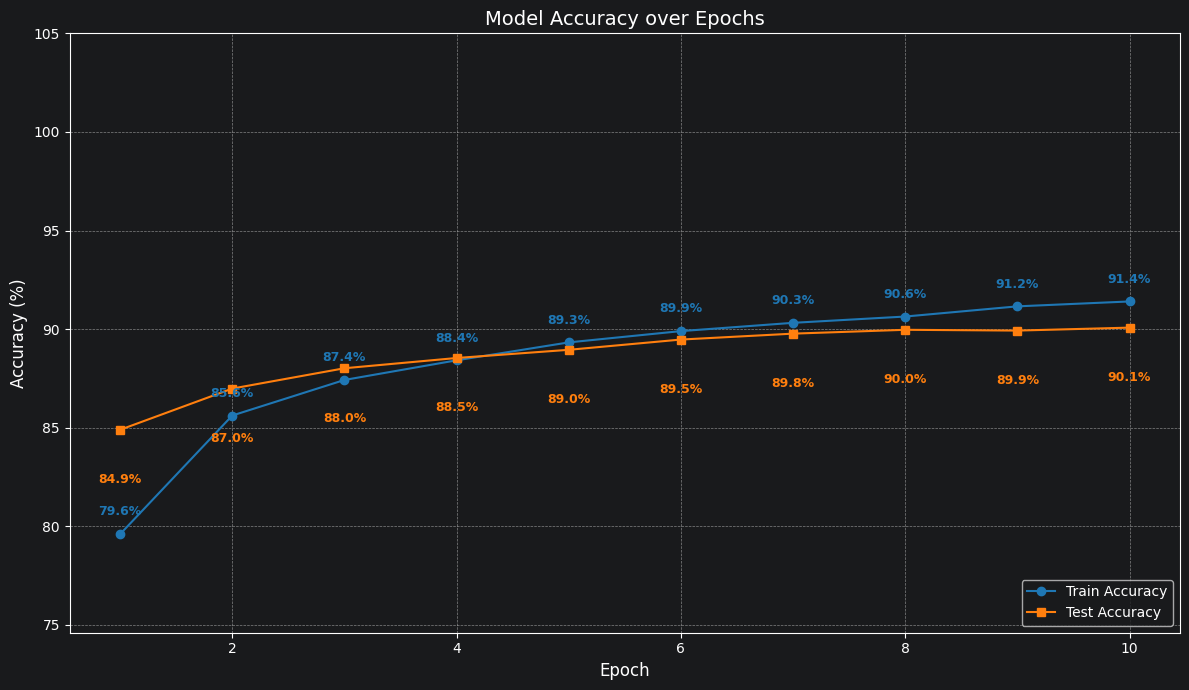

In [3]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
from torch.utils.data import Dataset, DataLoader, random_split
from torchvision import transforms


class QuickDrawDataset(Dataset):
    def __init__(self, root, categories, max_items=10000, transform=None):
        self.data, self.labels = [], []
        self.transform = transform

        for idx, cat in enumerate(categories):
            # Load as raw uint8 (0-255)
            data = np.load(f"{root}/{cat}.npy")[:max_items]
            self.data.append(data)
            self.labels.extend([idx] * len(data))

        self.data = np.concatenate(self.data).astype(np.uint8)
        self.labels = np.array(self.labels)

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        image = self.data[idx].reshape(28, 28)
        label = self.labels[idx]

        # Apply transforms
        if self.transform:
            image = self.transform(image)
        return image, label


# Model Definition

class Net(nn.Module):
    def __init__(self):
        super(Net, self).__init__()
        self.flatten = nn.Flatten()

        self.layers = nn.Sequential(
            nn.Linear(784, 128),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(128, 10),
            nn.LogSoftmax(dim=1)
        )

    def forward(self, x):
        x = self.flatten(x)
        logits = self.layers(x)
        return logits


class CNN(nn.Module):
    def __init__(self):
        super(CNN, self).__init__()

        self.convolution = nn.Sequential(
            nn.Conv2d(1, 6 , kernel_size=5),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2),
            nn.Conv2d(6 , 16, kernel_size=5),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2)
        )

        self.flatten = nn.Flatten()

        self.FNN = nn.Sequential(
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(128, 10),
            nn.LogSoftmax(dim=1)
        )

    def forward(self, x):
        x = self.convolution(x)
        # print(x.shape)
        x = self.flatten(x)
        # print(x.shape)
        x = self.FNN(x)
        return x


# Setup
transform = transforms.Compose([
    transforms.ToTensor(),
])

dataset = QuickDrawDataset("./data", categories, transform=transform)

basicNN = Net()

CNN = CNN()


# Training

def train_and_graph(model, train_loader, test_loader, epochs=10, lr=0.001):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model.to(device)

    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    criterion = nn.NLLLoss()

    train_acc_history = []
    test_acc_history = []

    print(f"Training on {device}...")

    for epoch in range(epochs):
        model.train()
        correct_train = 0
        total_train = 0

        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)

            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            _, predicted = torch.max(outputs.data, 1)
            total_train += labels.size(0)
            correct_train += (predicted == labels).sum().item()

        train_acc = 100 * correct_train / total_train
        train_acc_history.append(train_acc)

        model.eval()
        correct_test = 0
        total_test = 0

        with torch.no_grad():
            for images, labels in test_loader:
                images, labels = images.to(device), labels.to(device)
                outputs = model(images)
                _, predicted = torch.max(outputs.data, 1)
                total_test += labels.size(0)
                correct_test += (predicted == labels).sum().item()

        test_acc = 100 * correct_test / total_test
        test_acc_history.append(test_acc)

        print(f"Epoch [{epoch + 1}/{epochs}] - Train Acc: {train_acc:.2f}%, Test Acc: {test_acc:.2f}%")

    plt.figure(figsize=(12, 7))
    epochs_range = range(1, epochs + 1)

    plt.plot(epochs_range, train_acc_history, label='Train Accuracy', marker='o', color='#1f77b4')
    plt.plot(epochs_range, test_acc_history, label='Test Accuracy', marker='s', color='#ff7f0e')

    for i, (train_val, test_val) in enumerate(zip(train_acc_history, test_acc_history)):
        plt.text(i + 1, train_val + 0.8, f'{train_val:.1f}%',
                 ha='center', va='bottom', fontsize=9, color='#1f77b4', weight='semibold')


        plt.text(i + 1, test_val - 2.2, f'{test_val:.1f}%',
                 ha='center', va='top', fontsize=9, color='#ff7f0e', weight='semibold')

    plt.title('Model Accuracy over Epochs', fontsize=14)
    plt.xlabel('Epoch', fontsize=12)
    plt.ylabel('Accuracy (%)', fontsize=12)
    plt.legend(loc='lower right')
    plt.grid(True, linestyle='--', alpha=0.7)

    plt.ylim(min(min(train_acc_history), min(test_acc_history)) - 5, 105)
    plt.tight_layout()
    plt.show()


train_size = int(0.8 * len(dataset))
test_size = len(dataset) - train_size
train_ds, test_ds = random_split(dataset, [train_size, test_size])

train_loader = DataLoader(train_ds, batch_size=64, shuffle=True)
test_loader = DataLoader(test_ds, batch_size=64, shuffle=False)

# Train the model
train_and_graph(basicNN, train_loader, test_loader, epochs=10)

# train_and_graph(CNN, train_loader, test_loader, epochs=10)


Drawing Canvas for Testing

In [ ]:
import numpy as np
from IPython.display import HTML, display
from google.colab import output
import cv2
import torch
import base64
import matplotlib.pyplot as plt

canvas_html = """
<div style="border: 1px solid #ccc; padding: 20px; width: 320px; text-align: center; background-color: #f9f9f9; border-radius: 10px;">
    <canvas id="main_canvas" width="280" height="280" style="border:2px solid #000; cursor: crosshair; background-color: black;"></canvas>
    <br><br>
    <button id="clear_btn" style="padding: 10px 20px; cursor: pointer;">Clear</button>
    <button id="finish_btn" style="padding: 10px 20px; cursor: pointer; background-color: #4CAF50; color: white; border: none; border-radius: 5px;">Predict</button>
</div>

<script>
    var canvas = document.getElementById('main_canvas');
    var ctx = canvas.getContext('2d');
    var finish_btn = document.getElementById('finish_btn');
    var clear_btn = document.getElementById('clear_btn');
    var drawing = false;

    ctx.strokeStyle = "white";
    ctx.lineWidth = 10;
    ctx.lineCap = "round";
    ctx.lineJoin = "round";

    canvas.addEventListener('mousedown', (e) => { drawing = true; ctx.beginPath(); ctx.moveTo(e.offsetX, e.offsetY); });
    canvas.addEventListener('mousemove', (e) => { if(drawing) { ctx.lineTo(e.offsetX, e.offsetY); ctx.stroke(); } });
    canvas.addEventListener('mouseup', () => { drawing = false; });

    clear_btn.onclick = () => { ctx.clearRect(0, 0, canvas.width, canvas.height); };

    // This function returns a promise that Colab's eval_js will wait for
    var getCanvasData = new Promise(resolve => {
        finish_btn.onclick = () => {
            resolve(canvas.toDataURL('image/png'));
        };
    });
</script>
"""


def get_prediction():
    display(HTML(canvas_html))

    data_url = output.eval_js("getCanvasData")

    try:
        header, encoded = data_url.split(",", 1)
        binary = base64.b64decode(encoded)
        nparr = np.frombuffer(binary, np.uint8)

        # Read as BGR then convert to Gray to handle transparency/alpha correctly
        img = cv2.imdecode(nparr, cv2.IMREAD_UNCHANGED)
        if img.shape[-1] == 4:  # If there's an alpha channel
            # Create a black background and paste the drawing onto it
            background = np.zeros((280, 280), dtype=np.uint8)
            alpha_channel = img[:, :, 3]
            img_gray = alpha_channel  # In our canvas, alpha represents the white strokes
        else:
            img_gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

        # Resize and Normalize
        img_28 = cv2.resize(img_gray, (28, 28), interpolation=cv2.INTER_AREA)

        # Match the QuickDraw format (0 to 1 range)
        img_tensor = torch.from_numpy(img_28).float() / 255.0
        # normalization
        img_tensor = (img_tensor - 0.5) / 0.5
        img_tensor = img_tensor.unsqueeze(0).unsqueeze(0).to(device)

        # Prediction
        model.eval()
        with torch.no_grad():
            output_logits = model(img_tensor)
            ps = torch.softmax(output_logits, dim=1)
            prob, pred_idx = torch.max(ps, 1)

        # Visual Result
        # Mapping index back to class name
        label = categories[pred_idx.item()] if 'categories' in globals() else pred_idx.item()

        plt.figure(figsize=(3, 3))
        plt.imshow(img_28, cmap='gray')
        plt.title(f"Result: {label}\nConf: {prob.item() * 100:.1f}%")
        plt.axis('off')
        plt.show()

    except Exception as e:
        print(f"Error: {e}")


# Run the test
get_prediction()